MICROGRAD implements backpropogation over a DAG and a small NN library on top of it with a PyTorch-like API.

# MICROGRAD is a tiny neural network engine.

In [82]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

A variable is "dumb". It only holds a single value and has no memory of the previous steps. To have backpropogation, our node must know what they came from.
We solve this issue by wrapping our data in a Value object, which contains: the data, how it was created, and the data that was previously used to create the node.

Note that `__ repr __` returns the value we want to print. Without it, we would instead get an address.

In [83]:
class Value:  # creates a function 'Value'

  def __init__(self, data): # wraps data inside Value
    self.data = data

  def __repr__(self): # returns what happens when you print it
    return f"Value(data={self.data})"

In [84]:
a = Value(2.0) # in this case, self.data = 2.0
print(a)

Value(data=2.0)


However, adding two Value variables causes an error, as it is considered an "unsupported operand type".

To handle this, we can create a function to handle addition.

We can also do this for multiplication.

In [85]:
class Value:

  def __init__(self, data):
    self.data = data

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other): # takes in two Value parameters
    out = Value(self.data + other.data)
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data)
    return out

In [86]:
a = Value(1.0)
b = Value(-3.0)
c = Value(4.0)
a * b + c # internally: (a.__mul__(b)).__add__(c)

Value(data=1.0)

Now, we want to have Value retain memory of what created it (in this case, it would be what its parents were).

In [87]:
class Value:

  def __init__(self, data, _children=()): # the parameter 'children' is a tuple
    self.data = data
    self._prev = set(_children) # tuple --> empty set

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other))
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other))
    return out

In [88]:
a = Value(2.0)
b = Value(-3.0)
c = a + b
c._prev # gets me the previous step

{Value(data=-3.0), Value(data=2.0)}

Now, we know the parents of each value, but we do not know what operator was used.
We can add this below:

Note: the 'label' parameter will be used for graphing purposes.

In [89]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._prev = set(_children)
    self._op = _op # what operation produced this node
    self.label = label # for graphviz below

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    return out

In [90]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = a * b; c.label = 'c'
d = c + Value(10.0); d.label = 'd'
e = d * Value(-2.0); e.label = 'e'
f = Value(-2.0); f.label = 'f'
L = e + f; L.label = 'L'

d._op # gets me the previous operand

'+'

We can see this visually.

In [91]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.1f }" % (n.label, n.data, ), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

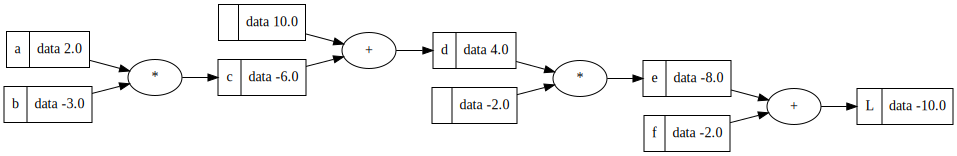

In [92]:
draw_dot(L)

From this point, we can do backpropogation.
In essence, we want to start at 'L' and work our way back.

We can think of this as finding the derivative of each previous node with respect to L.

Note that the data remains constant, but the weights of the data will be reiterated via gradient descent.

In [93]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0 # a zero value essentially means no effect
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    return out

a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [94]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.1f | grad %.1f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

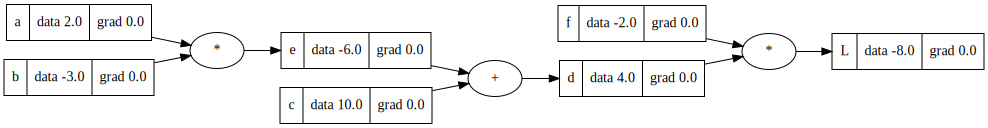

In [95]:
draw_dot(L)

Now we can start back propogation.
We start at L, where we are interested in filling in the gradient value at data point L.

We can think of the gradient as: if we move L a value h (for h approaches 0), how much does the gradient move? This is the same as finding the derivative.

In [96]:
def lol():  # does not affect global variables

  h = 0.001

  a = Value(2.0, label = 'a')
  b = Value(-3.0, label = 'b')
  c = Value(10.0, label = 'c')
  e = a * b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label = 'f')
  L = d * f; L.label = 'L'
  L1 = L.data

  a = Value(2.0 + h, label = 'a')
  b = Value(-3.0, label = 'b')
  c = Value(10.0, label = 'c')
  e = a * b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label = 'f')
  L = d * f; L.label = 'L'
  L2 = L.data

  print((L2 - L1) / h)  # limit definition of a derivative

lol()

6.000000000000227


The gradient value at L with respect to L is 1.0 (set `L2 = L.data + h`)
So, we can manually set the gradient value at L to 1.0.

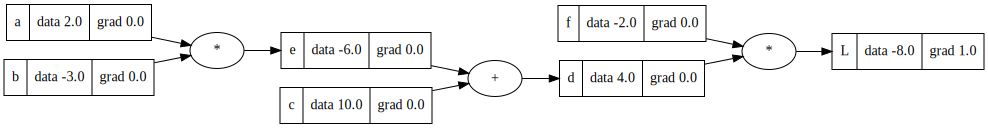

In [97]:
L.grad = 1.0
draw_dot(L)

Let us continue our backpropogation journey.
The nodes that precede L are points d and f. Start with point d.

In essence, we are finding the derivative of d with respect to L.

Mathematically, `L = d * f`, where we want dL/dd. If we just differentitate both sides by d, we arrive at `dL = 1 dd * f`. Solving for our derivative we get dL/dd = f.

Symetrically, the gradient for point f would be the data value of d.

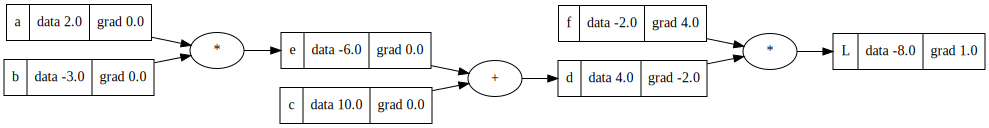

In [98]:
f.grad = d.data
d.grad = f.data
draw_dot(L)

Next, we want to find the gradient of c. What that means is dL/dc.

First, we find dd/dc.
`d = c + e`
Deriving it gives us `dd/dc = 1.0`.

By symmetry, `dd/de = 1.0`.

We can find dL/dc via Chain Rule.
`dL/dc = dL/dd * dd/dc = -2.0 * 1.0 = -2.0`.
Similarly, `dL/de = dL/dd * dd/de = -2.0 * 1.0 = -2.0`.

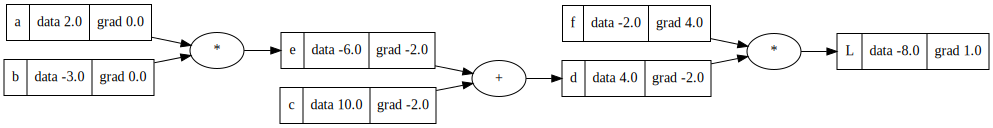

In [99]:
c.grad = -2.0
e.grad = -2.0
draw_dot(L)

To find a or b, we can continuing applying the derivative (and Chain Rule).

Given dL/de = -2.0 and we want dL/da, we have `dL/da = dL/de * de/da = -2.0 * b.data`.
Now, `dL/db = dL/de * de/db = -2.0 * a.data`.

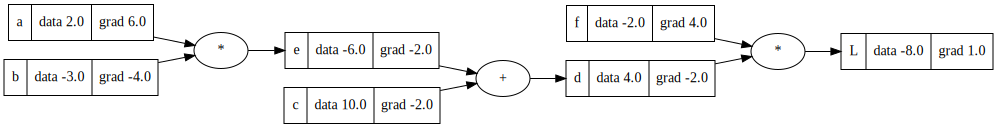

In [100]:
a.grad = -2.0 * b.data
b.grad = -2.0 * a.data
draw_dot(L)

We can nudge each data value by a small amount to execute a forward pass (which verifies our backpropogation works).

In [101]:
h = 0.01
a.data += h * a.grad
b.data += h * b.grad
c.data += h * c.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.4352


Above, we see that the value of L after nudging it is -7.4532.
That means, by increasing each value by 0.01, L increased by `(-7.4532 - (-8.0) = 0.5468)`.

So, the gradient (or slope) of L would be `0.5468 / h = 54.68`.


This means that, for every 1 increase in our original value, our final value, L, increases by roughly 54.68.

# Neural Network:

When modeling a neural network, the values are usually squished to produce nonlinearity (makes the network more dynamic)
We call these squishing methods **activation functions**.

Below is an example of an activation function known as tanh.
It squeezes all values into a range from -1 to 1.

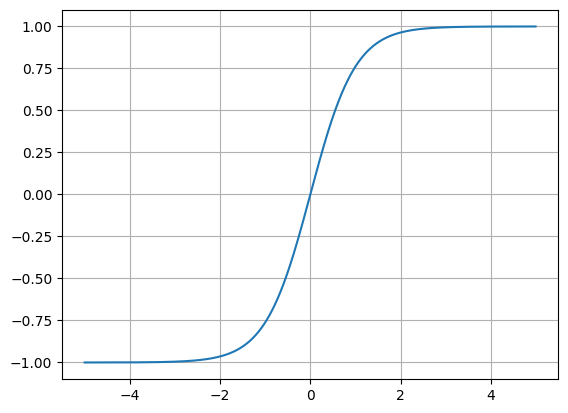

In [102]:
plt.plot(np.arange(-5, 5, 0.01), np.tanh(np.arange(-5, 5, 0.01)));
plt.grid();

To illustrate this better, we can write out a neural network.

In [103]:
# x1 and x2 are inputs to a two-dimensional neural network (2 parameters are going to come in)
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights w1 and w2. They represent synaptic strengths for each input
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neural network
b = Value(6.7, label = 'b')

# x1 * w1 + x2 * w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

Note that `n` is known as the pre-activation value (the value BEFORE the activation function is applied).

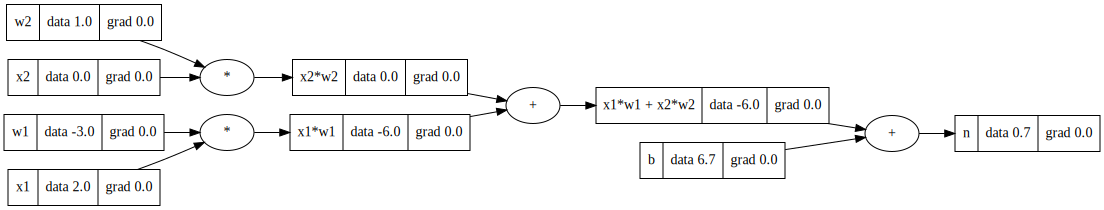

In [104]:
draw_dot(n)

Next, let us apply the activation function (tanh).

HOWEVER, tanh() is a hyperbolic function, which comprises of e^x, which our Value function does not currently have.

In [105]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    return out

  def tanh(self):
    n = self.data
    t = (math.exp(2 * n) - 1) / (math.exp(2 * n) + 1) # this is the exponential definition for tanh
    out = Value(t, (self, ), 'tanh')
    return out

a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [106]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

Now we have our tanh() function, we can use it.

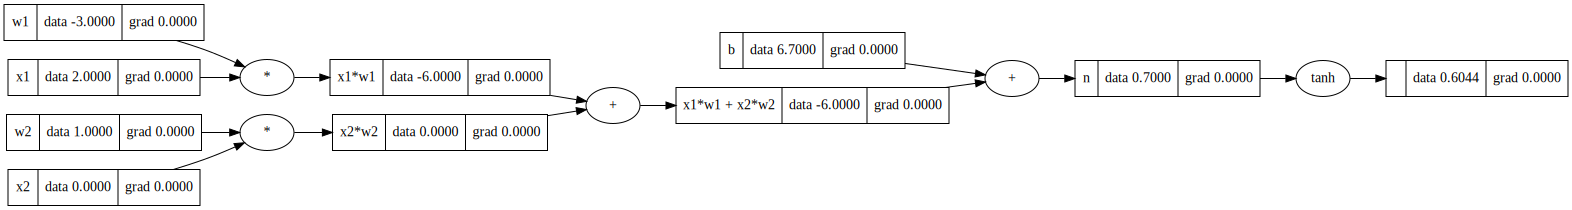

In [107]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.7, label = 'b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh()
draw_dot(o)

As we see above, n is not being squished too much.
We can increase the bias to see how it gets passed through the activation function.


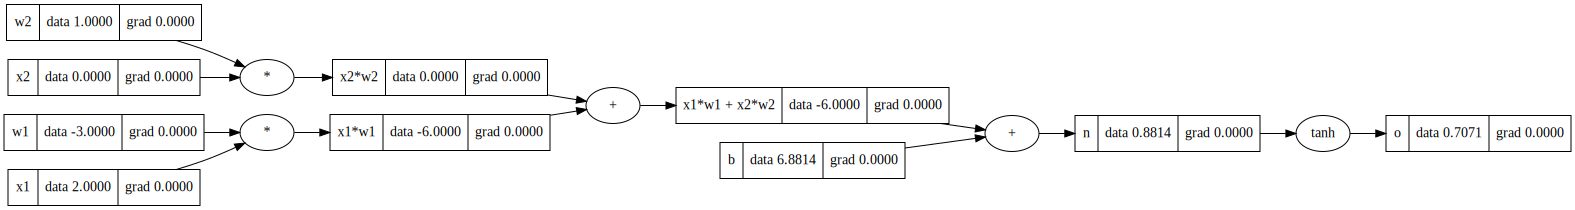

In [108]:
b = Value(6.8813735870195432, label = 'b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'
draw_dot(o)

Letting the bias being b = 6.8813735870195432 is for convienence sake.

Now, we can begin backpropogation.
Earlier, we discussed that the last point has a gradient of 1.0 (derivative of o with respect to o is just 1.0).

In [109]:
o.grad = 1.0

Next, we want the derivative of tanh with respect to point o.

The derivative of `tanh(n) = 1 - tanh(n)^2`. Therefore, `do/dn = 1 - o^2`.

In [110]:
print(1 - o.data ** 2)

0.4999999999999999


This is very close to 0.5. For simplifcation sake, we will set the gradient of n to be 0.5.

In [111]:
n.grad = 0.5

Let's continue stepping through our backpropogation. The operand that precedes n is an addition operand, which we discovered earlier to just be a gradient distributor (the derivative of each of those values with respect to n is just 1.0)

In [112]:
x1w1x2w2.grad = n.grad
b.grad = n.grad

By this idea, the same gradient rule also applies x1w1 and x2w2 (their operand is an addition sign).

In [113]:
x1w1.grad = n.grad
x2w2.grad = n.grad

Lastly, we can find the gradients of x1, w1, x2, and w2.

We found that the gradient in a multiplier is just the value of the other point times the gradient of the resulting Value.

In [114]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [115]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

Now that we manually found each gradient, we can update it in our graph.

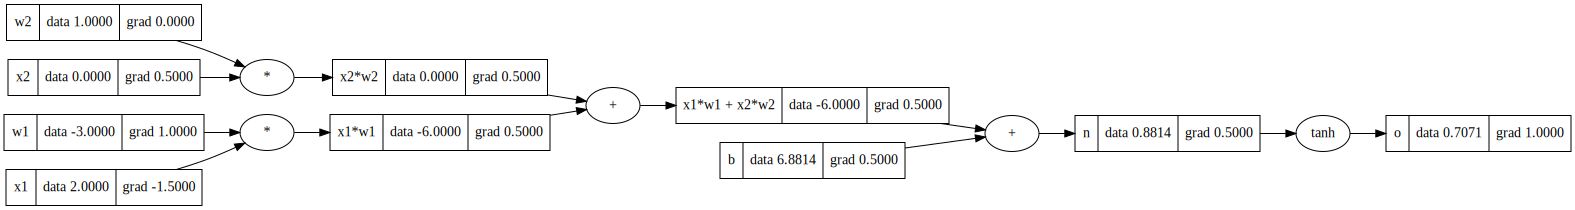

In [116]:
draw_dot(o)

Congrats! We have completed backpropogation!
Of course, this is a ridiculous process. It would take forever to manually calculate the gradient of thousands of nodes.

We can solve this by automating this process.

In [117]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None # creates an empty function; leaf node
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad = 1.0 * out.grad
      other.grad = 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad
    out._backward = _backward

    return out

  def tanh(self):
    n = self.data
    t = (math.exp(2 * n) - 1) / (math.exp(2 * n) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad = (1 - t ** 2) * out.grad
    out._backward = _backward

    return out

a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

We have now defined the backward steps for each function. To test it, we can undo our manual backpropogation and instead automate the process.

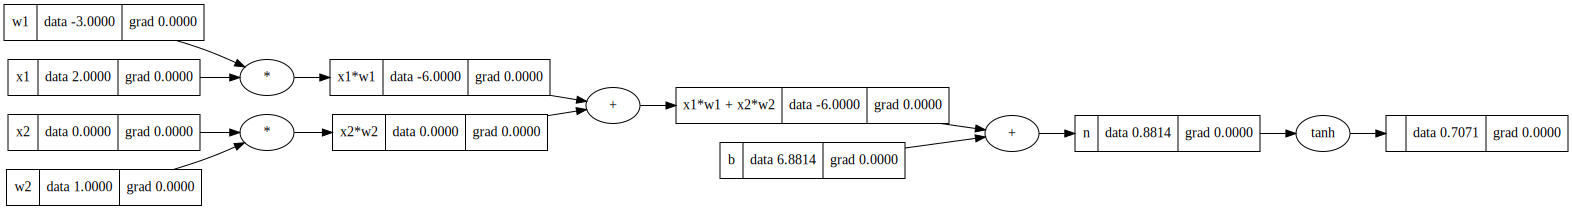

In [118]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); label = 'o'
draw_dot(o)

Below, `o.grad = 1.0` must be added because the gradient is multiplied to create a new gradient. Anything multipled by zero is zero, so we need to account for this possibility.

Then, we can perform `o._backward()` to initialize our backpropogation.

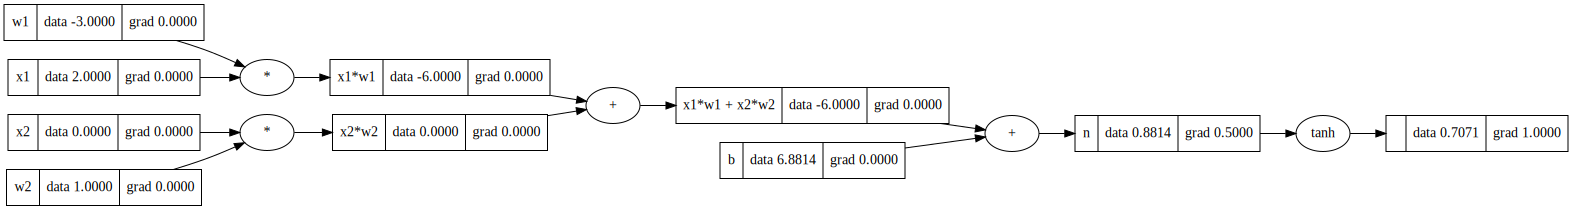

In [119]:
o.grad = 1.0
o._backward()
draw_dot(o)

Now that we see the gradient for n is 0.5, we can backpropogate again.

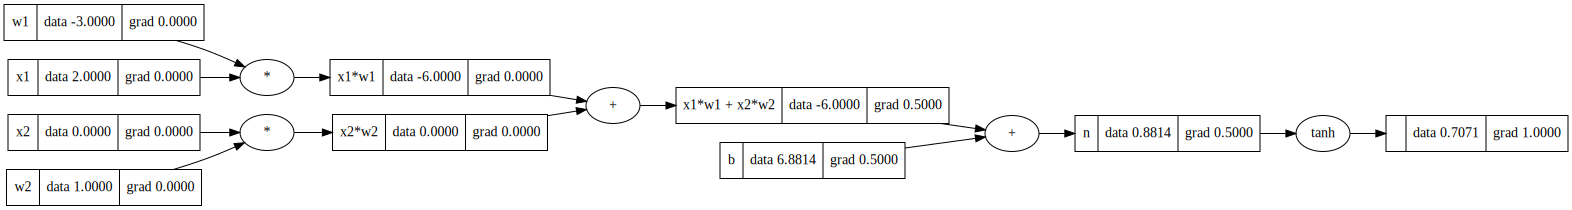

In [120]:
n._backward()
draw_dot(o)

We can continue this idea.

If we look at the graph, we see that the bias does not have any parents (therefore it cannot backpropogate).
This is covered by setting the initial backward to `lambda: None`.

It creates a null function that the neural network can call without any errors.

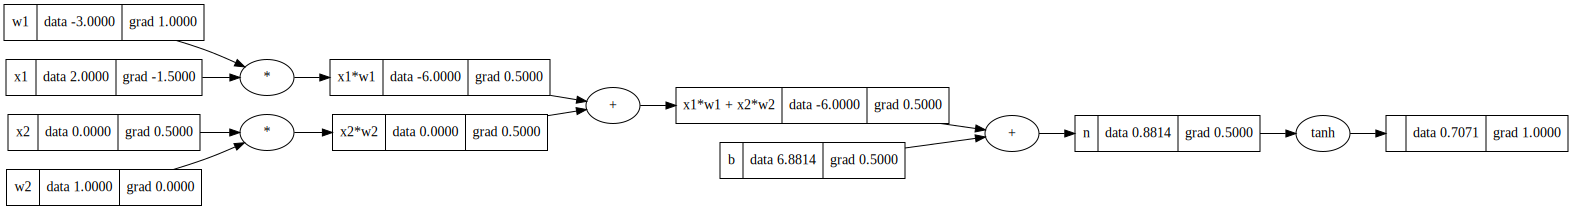

In [121]:
b._backward()
x1w1x2w2._backward()

x1w1._backward()
x2w2._backward()

x1._backward()
w1._backward()
x2._backward()
w2._backward()

draw_dot(o)

This simplifies backpropogation.

Our last piece of the puzzle is to call backwards propogation on ALL of the nodes.

Before we can even being backpropogation, we must gather all of the dependacies that come before. We can sort all of it via topological sort (a linear ordering of a directed acyclic graph---aka DAG).

In [122]:
# topological sort!

topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

Now that we have our nodes in order from first to last (left to right), we can use it to backpropogate.

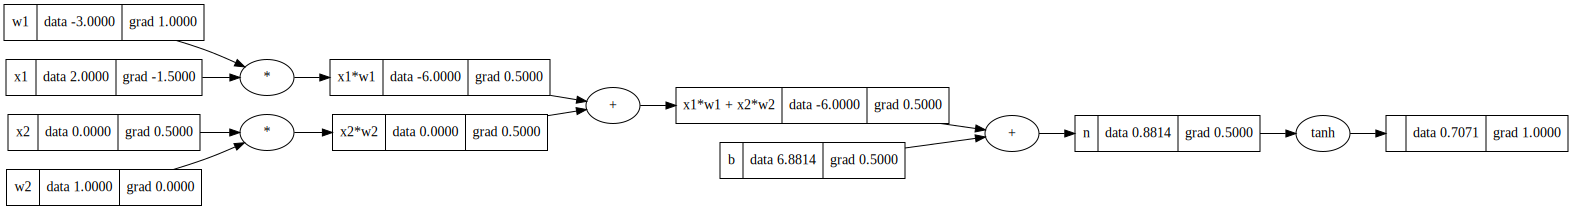

In [123]:
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

for node in reversed(topo): # reversal is needed since we want right to left (backpropogation)
  node._backward()

draw_dot(o)

Here, we see that we have successfully simplified backpropogation!

Now, we want to put this code inside our Value class to keep things neat.

In [124]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None # creates an empty function; leaf node
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad = 1.0 * out.grad
      other.grad = 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad
    out._backward = _backward

    return out

  def tanh(self):
    n = self.data
    t = (math.exp(2 * n) - 1) / (math.exp(2 * n) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad = (1 - t ** 2) * out.grad
    out._backward = _backward

    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad = 1.0 # same as o.grad = 1.0 previously

    for node in reversed(topo):
      node._backward()

a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

Now we have our function, we can call it to see if it works:

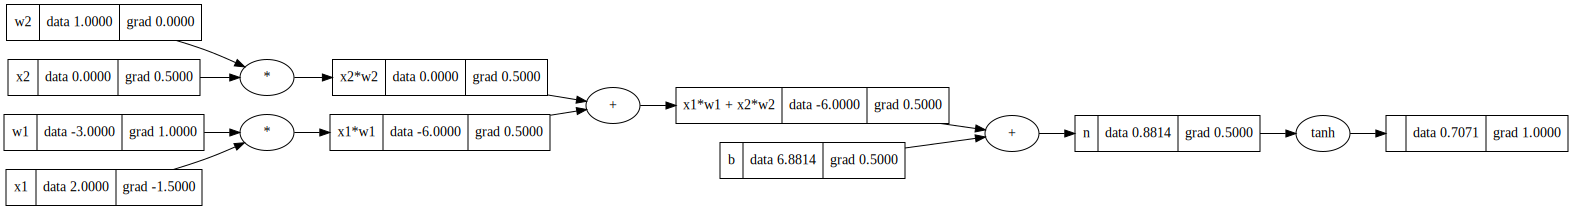

In [125]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.tanhlabel = 'o'

# our backpropogation
o.backward()
draw_dot(o)

HOLD! There is a bug that we must address. Take the following code for example:

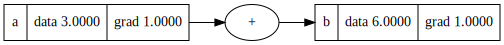

In [126]:
a = Value(3.0, label = 'a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

We realize that the gradient for a is not true.

The derivative of a with respect to b is 2, not 1.
In our code, we realize that the gradient is being overwritten by just 1.0. Instead of adding on the derivative, we are overriding it.


Solution:

In [127]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None # creates an empty function; leaf node
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def tanh(self):
    n = self.data
    t = (math.exp(2 * n) - 1) / (math.exp(2 * n) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t ** 2) * out.grad
    out._backward = _backward

    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad = 1.0 # same as o.grad = 1.0 previously

    for node in reversed(topo):
      node._backward()

a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

Instead of `self.grad = 1.0 * out.grad`, we now have `self.grad += 1.0 * out.grad`. This adds on the derivative, not overriding it.

Now, if we test:

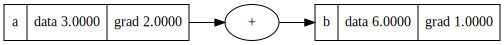

In [128]:
a = Value(3.0, label = 'a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

Great, we finalized our backpropogation.

Now, we can polish some tiny aspects of our code to make it better.
One problem we have is that we are unable to add a Value with a float or integer value. This is because the addition function defined in Value is `(self, other)`, where we try to access `other.data`.

In [129]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other):  # for other * self cases
    return self * other

  def tanh(self):
    n = self.data
    t = (math.exp(2 * n) - 1) / (math.exp(2 * n) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t ** 2) * out.grad
    out._backward = _backward

    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad

    for node in reversed(topo):
      node._backward()

Let's test this:

In [130]:
a = Value(2.0)
a + 1

Value(data=3.0)

However, one error we run into is if we have `2 * a` instead of `a * 2`. Python does not recognize this and instead flags it as an error.

We can solve this by creating a fallback function for multiply.
We call it `__rmul__`.

In [131]:
2 * a

Value(data=4.0)

Next, to break down our tanh function, we can create a exponential function.

In [132]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other):
    return self * other

  def tanh(self):
    n = self.data
    t = (math.exp(2 * n) - 1) / (math.exp(2 * n) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t ** 2) * out.grad
    out._backward = _backward

    return out

  def exp(self):  # function for e^x
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad  # the derivative of e^x is just e^x
    out._backward = _backward

    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad

    for node in reversed(topo):
      node._backward()

In [133]:
a = Value(2.0)
a.exp()

Value(data=7.38905609893065)

Lastly, the last component we need to fully break down tanh is division.
Instead of approaching this as `a/b`, we can have `a * 1/b`, or `a * b**-1`.

Additionally, we can add a power function to find the value of something to the power of -1.

In [134]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  # power function
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data ** other, (self, ), f'**{other}')

    def _backward():
      self.grad += other * (self.data ** (other - 1)) * out.grad  # Power rule
    out._backward = _backward

    return out

  def __rmul__(self, other):
    return self * other

  # division function
  def __truediv__(self, other):
    return self * other**-1

  def tanh(self):
    n = self.data
    t = (math.exp(2 * n) - 1) / (math.exp(2 * n) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t ** 2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward

    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad

    for node in reversed(topo):
      node._backward()

In [135]:
a = Value(2.0)
b = Value(4.0)
a / b

Value(data=0.5)

Lastly, we want a subtract function.

In [136]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data ** other, (self, ), f'**{other}')

    def _backward():
      self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __radd__(self, other):
    return self + other

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    return self * other**-1

  # negation function for subtraction function
  def __neg__(self):
    return self * -1

  # subtraction function
  def __sub__(self, other):
    return self + (-other)

  def tanh(self):
    n = self.data
    t = (math.exp(2 * n) - 1) / (math.exp(2 * n) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t ** 2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward

    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad = 1.0

    for node in reversed(topo):
      node._backward()

In [137]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

Now that we have all the components we need to dissect tanh, we can do exactly that:

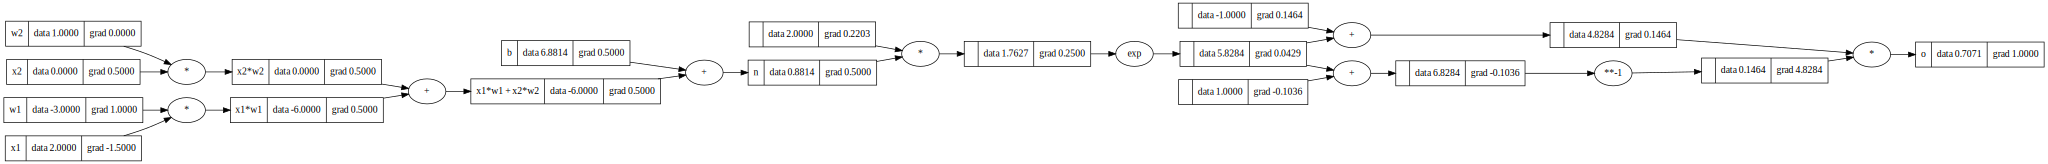

In [138]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

e = (2 * n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

o.grad = 1.0
o.backward()
draw_dot(o)

Next, we can build this neural network in PyTorch to get the same result.

In [139]:
import torch

In [140]:
# torch uses Tensors, which are n-dimensional arrays
# below, we use a one-dimension array to represent our scalar value
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1 * w1 + x2 * w2 + b # pre-activation value / forward pass
o = torch.tanh(n)

print(o.data.item())  # .item() strips the Tensor, leaving only the element
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


As we can see above, our output matches the gradients we manually derived.

This is considered more efficient as we can run in parallel.

We can now start building neurons, which are just a specific class of mathematical expressions.

First, we start with individual neurons until we build a two-dimension MLP.

In [141]:
import random

class Neuron:
  def __init__(self, nin):  # nin = number of inputs
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)] # random weights
    self.b = Value(random.uniform(-1, 1)) # a random bias

  def __call__(self, x):  # triggers when the function is called
    # forward pass: w * x + b
    act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)  # zip() = merges them together
    out = act.tanh()  # applies activation function
    return out

x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=-0.9997379424398949)

Next up, we want to define a layer of neurons.
A layer of neurons are not connected to each other, but are dependent on the previous layer.

In [142]:
class Layer:
  def __init__(self, nin, nout):  # nout = number of neurons we want in our layer
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs

x = [2.0, 3.0]
n = Layer(2, 3) # 3 2-dimensional neuron layer
n(x)

[Value(data=0.348830245005517),
 Value(data=-0.9354438276495387),
 Value(data=-0.37370470338084516)]

Lastly, a MLP is just a collection of nested layers.
We can build this function.

In [143]:
class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs # outputs all neurons

x = [2.0, 3.0]
n = Layer(2, 3)
n(x)

class MLP:
  def __init__(self, nin, nouts): # nouts = a list of outputs
    sz = [nin] + nouts  # combines input size with all the layer sizes
    self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1]) # 3 inputs with layer sizes of [4, 4, 1]
n(x)

Value(data=0.3625778399610674)

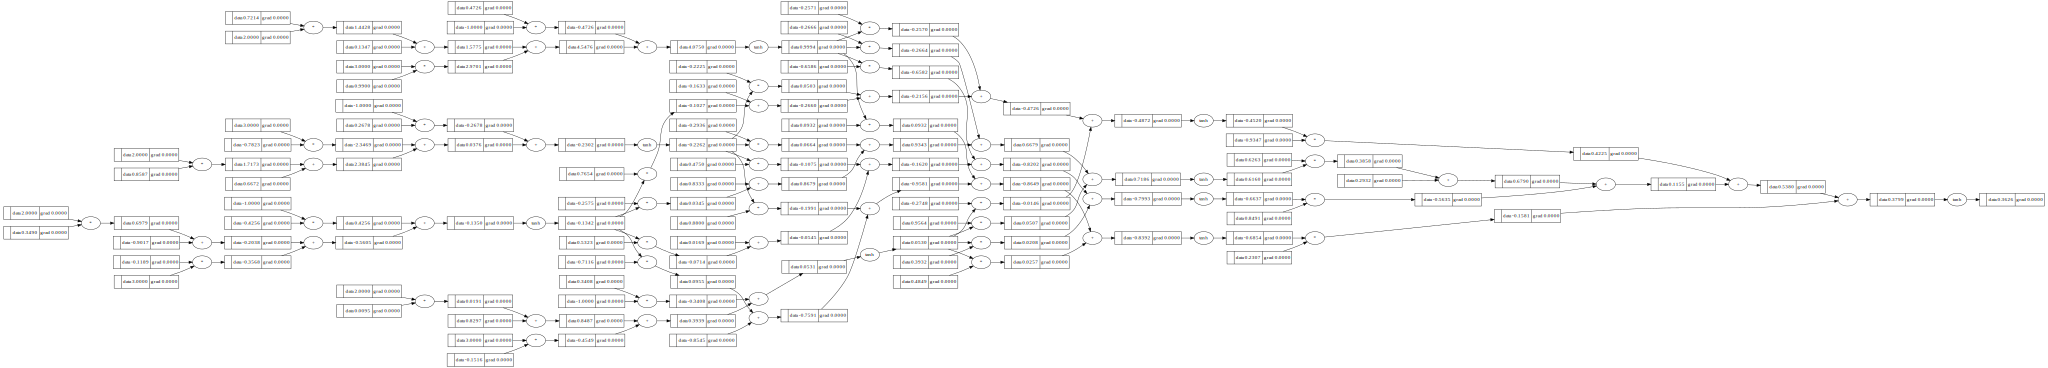

In [144]:
draw_dot(n(x))

It would be unwise to manually the compute the gradients of each of these nodes. We can use backpropogation of our micrograd to circumvent that.

Consider the example below.

In [145]:
xs = [
    [2.0, 3.0, -1.0], # we want this to return 1.0
    [3.0, -1.0, 0.5], # -1.0
    [0.5, 1.0, 1.0],  # -1.0
    [1.0, 1.0, -1.0], # 1.0
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets for binary classification
ypred = [n(x) for x in xs]  # predictions
ypred

[Value(data=0.3625778399610674),
 Value(data=0.93767807858871),
 Value(data=0.885968353294801),
 Value(data=0.7743698079299046)]

From our desired outputs, we want to push the first and fourth inputs up, while decreasing the second and third inputs (to match the desired result).

To do this, we have to create a function that can measure the total performance of the model.

We call this a loss function.

We want to minimize loss (lower loss means it is closer to our desired output).

In [146]:
[(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)] # MSE
# the closer the value is to our desired output, the smaller the loss

[Value(data=0.4063070101086986),
 Value(data=3.754596336243235),
 Value(data=3.5568766296295036),
 Value(data=0.05090898357358813)]

In [147]:
loss = sum([(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=7.768688959555025)

In [148]:
loss.backward()

Now, we can look at the first neuron in the first layer's weight.

In [149]:
n.layers[0].neurons[0].w[0].grad

0.9195156133855265

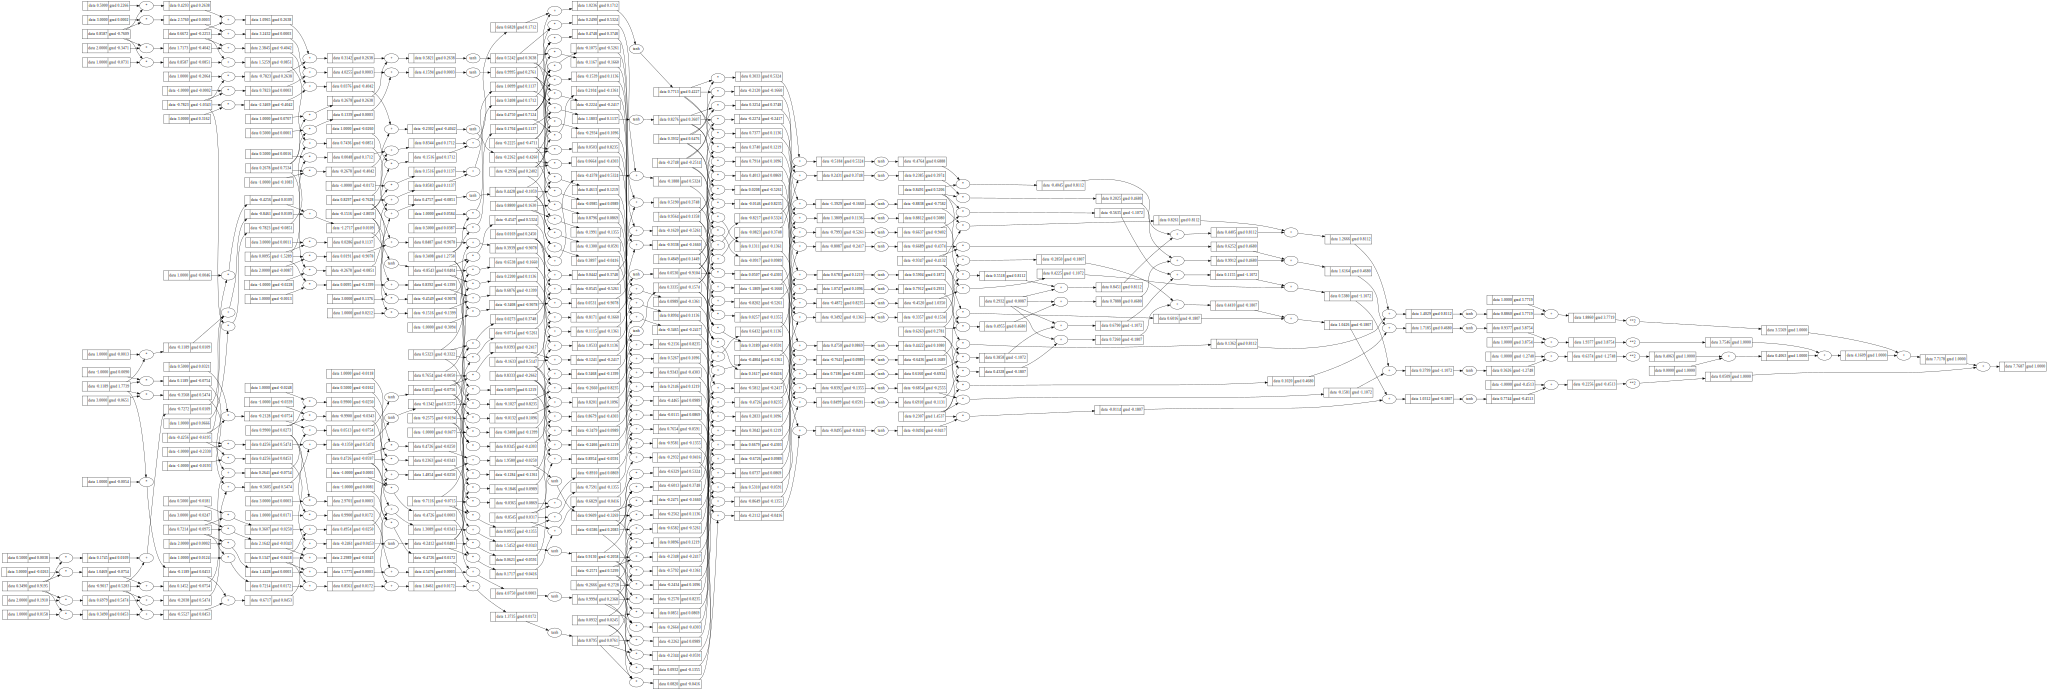

In [150]:
draw_dot(loss)

The loss function will backpropogate through EVERY intermediate function.

Next, we want to gather all the neurons so we can operate on them simultaneously.

In [151]:
import random

class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1, 1))

  def __call__(self, x):
    act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b] # list of all weights + list of all biases

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]
    # params = []
    # for neuron in self.neurons:
    #   ps = neuron.parameters()
    #   params.extend(ps)
    # return params

class MLP:
  def __init__(self, nin, nouts): # nouts = a list of outputs
    sz = [nin] + nouts  # combines input size with all the layer sizes
    self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [152]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

ypred = [n(x) for x in xs]  # forward pass on THIS n
loss = sum([(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)])
loss.backward()

In [153]:
n.parameters()  # all weights and biases in the NN

[Value(data=-0.5338724059663291),
 Value(data=-0.7473660031442904),
 Value(data=-0.47841317366348135),
 Value(data=0.9193243257793564),
 Value(data=-0.743882287299537),
 Value(data=-0.3300977079135625),
 Value(data=0.8012698669378646),
 Value(data=-0.32637540771471163),
 Value(data=0.9588085587320831),
 Value(data=-0.9182401268105631),
 Value(data=-0.9851340815996281),
 Value(data=0.35992320871366745),
 Value(data=0.9151703974413168),
 Value(data=-0.5297496318762207),
 Value(data=-0.21098089565580702),
 Value(data=0.7004749039942968),
 Value(data=-0.28156241829595396),
 Value(data=0.3634142097569171),
 Value(data=0.18768097335063394),
 Value(data=-0.1614521836981475),
 Value(data=-0.799791438093721),
 Value(data=-0.37340662106009925),
 Value(data=-0.13597786835042758),
 Value(data=0.7149204072832376),
 Value(data=-0.5289815946979783),
 Value(data=0.9484591926742971),
 Value(data=0.4058797285435978),
 Value(data=0.12305825574367746),
 Value(data=-0.11882266782949058),
 Value(data=-0.811

In [154]:
len(n.parameters())

41

Once more, we can see the weight and data of each individual neuron.

In [155]:
n.layers[0].neurons[0].w[0].grad

1.3753668810190762

In [156]:
n.layers[0].neurons[0].w[0].data

-0.5338724059663291

We want to slightly nudge each neuron so that it matches our desired output.

We want to push the value in a step size towards the gradient.
Note: the multiplier to `p.grad` is known as the **learning rate**.

In [157]:
for p in n.parameters():
  p.data += -0.01 * p.grad  # we want to step away from gradient descent

In [158]:
n.layers[0].neurons[0].w[0].data  # slightly increased

-0.5476260747765199

In [159]:
ypred = [n(x) for x in xs]  # smaller loss value
loss = sum([(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=3.7837807769266902)

Now we can iterate through the step process until our loss function reaches zero.

We can see that setting a good learning rate is integral. Set it too small: the process would take too long. Set it too large: gradient descent may overstep.

In [160]:
xs = [
    [2.0, 3.0, -1.0], # we want this to return 1.0
    [3.0, -1.0, 0.5], # -1.0
    [0.5, 1.0, 1.0],  # -1.0
    [1.0, 1.0, -1.0], # 1.0
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets for binary classification

In [161]:
for k in range(20):
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum([(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)])

  # backward pass
  for p in n.parameters():
    p.grad = 0.0  # zeroes out all the gradients so it does not accumulate
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k, loss.data)

0 3.7837807769266902
1 3.4255069884942024
2 3.112179422336826
3 2.796680538580704
4 2.4699834763357047
5 2.1120982321976944
6 1.674080873425109
7 1.118086154059244
8 0.5944335945873481
9 0.32988726536874347
10 0.22441066199163132
11 0.17141351566800855
12 0.13929829502887398
13 0.11754199735827645
14 0.10172619650598774
15 0.08966246128108978
16 0.08013472762872324
17 0.0724086899045825
18 0.06601241065563165
19 0.060627552645170515


In [162]:
ypred

[Value(data=0.8658911724390482),
 Value(data=-0.9008555641931938),
 Value(data=-0.8637042139404792),
 Value(data=0.8806843909357839)]

As we can see above, the algorithm pushes the loss value to an incredibly small value.

Additionally, we see that our `ypred` values are actually much closer to the desired ouput.

IT IS VERY IMPORTANT TO ZERO OUT THE GRADIENTS.